In [1]:
import sys, os
from pathlib import Path
from pprint import pprint
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import yaml
from tqdm import tqdm

BASE_DIR = Path.cwd().resolve().parent.parent
SCRIPT_DIR = Path.cwd().resolve()
sys.path.append(str(BASE_DIR))
group_name = 'fidelity_exp'
EXP_DIR = SCRIPT_DIR / group_name
EXP_CFG_DIR = EXP_DIR / 'configs'
RES_DIR = EXP_DIR / 'results'
CFG_DIR = SCRIPT_DIR / 'configs'

from experiment_board.anomaly_detection_journal_exps.simulated_experiment_classes import Experiment, hp_study, SNN_LOGN_GTVObjective, get_data, calculate_metrics

# plt.style.use('bmh')
plt.style.use('seaborn-v0_8-paper')
# Set the default font family to serif
plt.rcParams['font.family'] = 'serif' 
# Specify a list of font names to try for the serif family
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Palatino'] 

In [2]:
mpl.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [3]:
def load_study_results(group_name, config_name, model_name):
    """
    Load study results from a CSV file.
    """
    file_path = SCRIPT_DIR / group_name / 'results' / f"{config_name}_{model_name}.csv"
    if not file_path.exists():
        raise FileNotFoundError(f"Results file {file_path} does not exist.")
    
    df = pd.read_csv(file_path)
    return df

def convert_angle_to_cartesian_on_simplex(thetas):
    """Convert hyperparameters in spherical coordinates (thetas) to Cartesian coordinates on N-simplex.
    
    Args:
        thetas (np.ndarray): Angles in radians, shape (-1,N-1) where N is the number of dimensions.
    Returns:
        np.ndarray: Cartesian coordinates on N-simplex, shape (-1,N).
    """
    dim_1 = thetas.shape[0]; dim_2 = thetas.shape[1]
    thetas = np.array(thetas, dtype=np.float64)
    sin_thetas = np.concatenate([np.ones((dim_1,1)), np.sin(thetas)], axis=1)
    cos_thetas = np.concatenate([np.cos(thetas), np.ones((dim_1,1))], axis=1)
    x = (np.cumprod(sin_thetas, axis=1)*cos_thetas)**2
    return x

def load_exp_config(group_name, config_name):
    """
    Load experiment configuration from a YAML file.
    """
    with open(EXP_CFG_DIR / f'{config_name}.yaml') as f:
        exp_config = yaml.safe_load(f)
    return exp_config

def set_nested_value(data, keys, value):
    """
    Sets a value in a nested dictionary given a list of keys.

    Args:
        data (dict): The dictionary to modify.
        keys (list): A list of keys representing the path to the value.
        value: The value to set.
    """
    if not keys:
        return value
    if not isinstance(data, dict):
      data = {}
    data[keys[0]] = set_nested_value(data.get(keys[0], {}), keys[1:], value)
    return data

# Experiment 1: Varying SNR
## Part A: Fidelity vs Hard Constrained models under Varying SNR

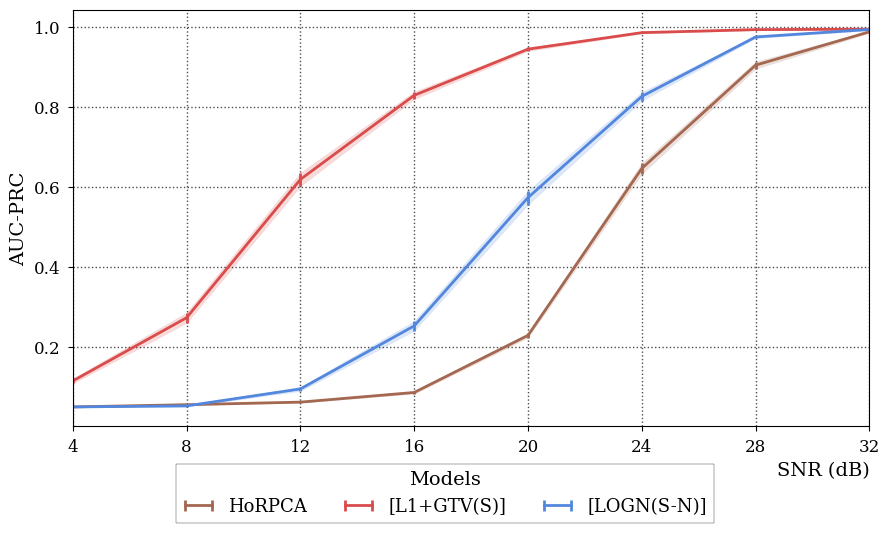

In [8]:
from matplotlib.legend_handler import HandlerErrorbar

group_name = "fidelity_exp"
EXP_DIR = SCRIPT_DIR / group_name
EXP_CFG_DIR = EXP_DIR / 'configs'
RES_DIR = EXP_DIR / 'results'
CFG_DIR = SCRIPT_DIR / 'configs'
def load_exp_config(group_name, config_name):
    """
    Load experiment configuration from a YAML file.
    """
    with open(EXP_CFG_DIR / f'{config_name}.yaml') as f:
        exp_config = yaml.safe_load(f)
    return exp_config

config_name = "coherent_SL_rel_err_tpe"
# Load the experiment configuration
exp_config = load_exp_config(group_name, config_name)
overwrite = True

independent_var = exp_config['independent_var']
model_configs = exp_config['models']
model_keys = list(model_configs.keys())
model_names = [model_configs[key]['name'] for key in model_keys if key.endswith('_F')]
short_model_names = [name.replace('[SNN]-', '') for name in model_names]
short_model_names

aggregate_path = RES_DIR / f"{config_name}_aggregate_results.csv"
aggregate_df = pd.read_csv(aggregate_path, index_col=['model_name', independent_var['keys'][-1]])
with open(CFG_DIR / 'model_plot_styles.yaml') as f:
    model_styles = yaml.safe_load(f)
model_name_to_key_map = {v['label']: k for k, v in model_styles.items()}


metrics = ['AUC-PRC']#, 'AUC-ROC']#, 'S_rel_err', 'L_rel_err']
titles = [None]#'Area Under the Precision-Recall Curve vs SNR (dB)']#,'Area Under the Receiver Operating Characteristic Curve vs SNR (dB)']
# Plotting
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
# fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(9, 9))
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 5))
if len(metrics) == 1:
    axes = np.array([axes])
else:
    axes = axes.flatten()

for i, metric in enumerate(metrics):
    # axes[i].set_title(f'Mean {metric} vs Varying {independent_var["keys"][-1]}', fontsize=18)
    axes[i].set_title(titles[i], fontsize=15)
    lines = []
    for model_name in model_names:
        model_aggregate = aggregate_df.loc[model_name]
        plot_style = model_styles[model_name_to_key_map[model_name]]
        plot_style['linewidth']=2.0
        plot_style['label'] = model_name.replace('[SNN]-', '')
        plot_style['linewidth']=2.0
        plot_style['label'] = model_name.replace('-f', '').replace('[SNN]-', '')
        plot_style['linestyle'] = '-'
        
        axes[i].errorbar(model_aggregate.index,
                    model_aggregate[metric],
                    yerr=model_aggregate[f'std_{metric}'],
                    **plot_style
                    )
        axes[i].fill_between(model_aggregate.index,
                             model_aggregate[metric] -model_aggregate[f'std_{metric}'],
                             model_aggregate[metric] +model_aggregate[f'std_{metric}'],
                             color=plot_style['color'],
                             alpha=0.2)
    axes[i].grid(True, linestyle='--', alpha=0.7, color='k')
    axes[i].set_ylabel(metric, fontsize=14, loc='center') # loc='top'
    # axes[i].tick_params(axis='x', rotation=45)
    # axes[i].legend(title='Models', fontsize=14)
    # axes[i].legend(title='Models', fontsize=13, edgecolor='k')
    
    axes[i].set_xlabel(independent_var['keys'][-1]+' (dB)', fontsize=14, loc='right')
    axes[i].set_xlim(aggregate_df.index.get_level_values(independent_var['keys'][-1]).min(),
                    aggregate_df.index.get_level_values(independent_var['keys'][-1]).max())
    axes[i].set_xticks(aggregate_df.index.get_level_values(independent_var['keys'][-1]).unique())
    axes[i].tick_params(axis='both', which='major', labelsize=12, labelrotation=0,
                        grid_linewidth=1, grid_linestyle=':')

handles, labels = axes[-1].get_legend_handles_labels()
# handles = [h.lines for h in handles]
handler_map = { h: HandlerErrorbar(numpoints=2, marker_pad=0.1, yerr_size=0.3) for h in handles}
figlegend_cfg = {   'loc': 'lower center',
                    # 'labelcolor':'markerfacecolor',
                    'ncol':3,
                    'framealpha':1.0,
                    'scatterpoints':2,
                    'title':'Models',
                    'title_fontsize':14,
                    'alignment': 'center',
                    'fontsize':13,
                    'edgecolor':'black',
                    # 'edgewidth':1.0,
                    'facecolor':'white',
                    # 'borderpad':0.5,
                    'bbox_to_anchor':(0, -0.075, 1, 0.2),
                    'bbox_transform':fig.transFigure,#axes[1].transAxes,
                    'handler_map':handler_map,
                    'handlelength':1.7,
                    'columnspacing':2.0,
                    'fancybox':False,
                    'frameon':True,
}
plt.figlegend(handles, labels, **figlegend_cfg)#, )
plt.tight_layout()
plt.show()

## Part B Incoherent signs vs Coherent signs

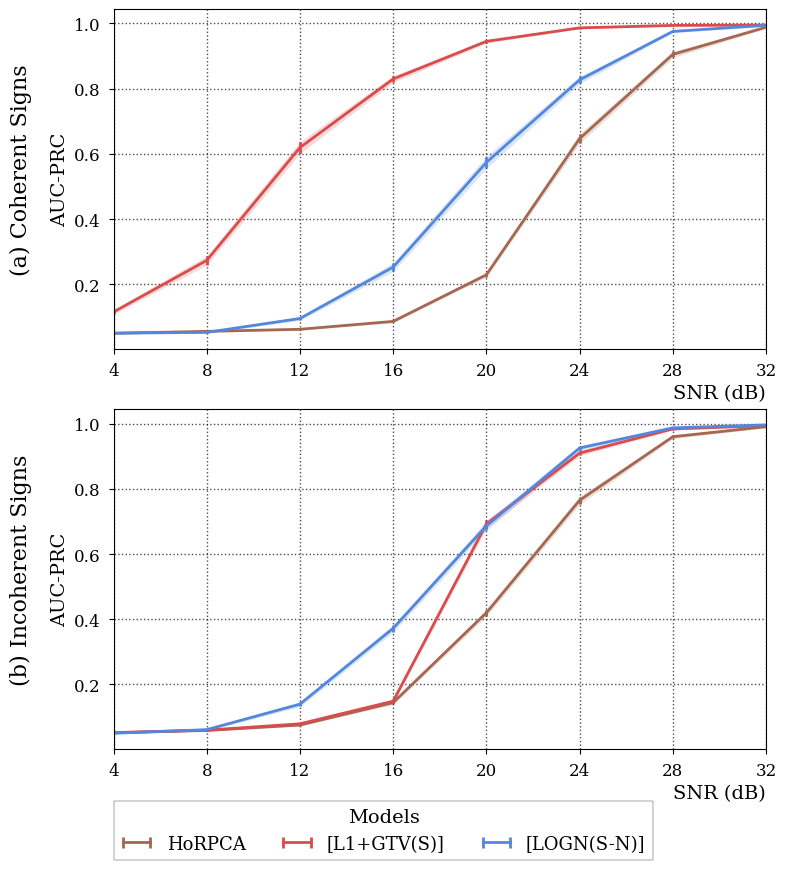

In [10]:
legend_cfg = { 'loc': 'lower right',
               'ncol':1,
               'framealpha':1.0,
               'scatterpoints':2,
               'title':'Models',
               'title_fontsize':14,
               'alignment': 'center',
               'fontsize':13,
               'edgecolor':'black',
               'facecolor':'white',
               'numpoints':2,
               'handlelength':2.5,
               'columnspacing':2.0,
               'fancybox':False,
               'frameon':True,
}

group_name = "fidelity_exp"
EXP_DIR = SCRIPT_DIR / group_name
EXP_CFG_DIR = EXP_DIR / 'configs'
RES_DIR = EXP_DIR / 'results'
CFG_DIR = SCRIPT_DIR / 'configs'
def load_exp_config(group_name, config_name):
    """
    Load experiment configuration from a YAML file.
    """
    with open(EXP_CFG_DIR / f'{config_name}.yaml') as f:
        exp_config = yaml.safe_load(f)
    return exp_config


coherent_config_name = "coherent_SL_rel_err_tpe"
incoherent_config_name = "incoherent_SL_rel_err_tpe"
# Load the experiment configuration
coherent_exp_config = load_exp_config(group_name, coherent_config_name)
incoherent_exp_config = load_exp_config(group_name, incoherent_config_name)

independent_var = incoherent_exp_config['independent_var']
model_configs = incoherent_exp_config['models']
# model_keys = list(model_configs.keys())
model_keys = ['HORPCA_F', 'SNN_L1_GTVS_F', 'SNN_LOGNSN_F']#, 'SNN_LOGNSN_GTVS_F']
model_names = [model_configs[key]['name'] for key in model_keys]

incoherent_aggregate_path = RES_DIR / f"{incoherent_config_name}_aggregate_results.csv"
coherent_aggregate_path = RES_DIR / f"{coherent_config_name}_aggregate_results.csv"
aggregate_dfs = [ pd.read_csv(coherent_aggregate_path, index_col=['model_name', independent_var['keys'][-1]]),
                  pd.read_csv(incoherent_aggregate_path, index_col=['model_name', independent_var['keys'][-1]])]
signs = ['coherent', 'incoherent']
with open(CFG_DIR / 'model_plot_styles.yaml') as f:
    model_styles = yaml.safe_load(f)
model_name_to_key_map = {v['label']: k for k, v in model_styles.items()}

metrics = ['AUC-PRC']# 'AUC-ROC']#, 'S_rel_err', 'L_rel_err']
# fig = plt.figure( figsize=(9,4.5))#(9, 8))
fig = plt.figure( figsize=(9, 8))
# fig.suptitle('Area Under the Precision-Recall Curve vs SNR', fontsize=16, y=1)

# Create subfigures for each row
subfigs = fig.subfigures(nrows=2, ncols=1)
# subfigs = [None,subfigs] if not isinstance(subfigs, np.ndarray) else subfigs.flatten()
rowtitles = ['(a) Coherent Signs',
            '(b) Incoherent Signs']

# Plotting
# fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 8))
# axes = axes.flatten()
for i in range(2):
    # i=1
    axes = subfigs[i].subplots(nrows=1, ncols=1)
    axes = [axes] if not isinstance(axes, np.ndarray) else axes.flatten()
    aggregate_df = aggregate_dfs[i]
    sign = signs[i]
    for j, metric in enumerate(metrics):
        # axes[0].set_title('Spatially ' +sign + ' signs', fontsize=14)
        for model_name in model_names:
            model_aggregate = aggregate_df.loc[model_name]
            plot_style = model_styles[model_name_to_key_map[model_name]]
            plot_style['linewidth']=2.0
            plot_style['label'] = model_name.replace('-f', '').replace('[SNN]-', '')
            plot_style['linestyle'] = '-'
            axes[0].errorbar(model_aggregate.index,
                        model_aggregate[metric],
                        yerr=model_aggregate[f'std_{metric}'],
                        **plot_style
                        )
            axes[0].fill_between(model_aggregate.index,
                                model_aggregate[metric] -model_aggregate[f'std_{metric}'],
                                model_aggregate[metric] +model_aggregate[f'std_{metric}'],
                                color=plot_style['color'],
                                alpha=0.2)
        axes[0].grid(True, linestyle='--', alpha=0.7, color='k')
        axes[0].set_ylabel(metric, fontsize=14, loc='center')
        axes[0].tick_params(axis='x', labelsize=12)
        # if i == 1:
        #     axes[0].legend(**legend_cfg)#title='Models', title_fontsize=13, edgecolor='k', loc='lower right', )
        
        axes[0].set_xlabel(independent_var['keys'][-1]+' (dB)', fontsize=14, loc='right')
        axes[0].set_xlim(aggregate_df.index.get_level_values(independent_var['keys'][-1]).min(),
                        aggregate_df.index.get_level_values(independent_var['keys'][-1]).max())
        axes[0].set_xticks(aggregate_df.index.get_level_values(independent_var['keys'][-1]).unique())
        axes[0].tick_params(axis='both', which='major', labelsize=12, labelrotation=0,
                        grid_linewidth=1, grid_linestyle=':')
    
    # axes[0].set_title('Spatially ' +sign + ' signs', fontsize=14)
    # subfigs[i].supylabel(rowtitles[i], fontsize=14)
    subfigs[i].subplots_adjust(left=0.175, bottom=0.05, top=0.90)
    subfigs[i].supylabel(rowtitles[i], fontsize=16, y=0.5, x=0.06)

# fig.tight_layout()
# fig.show()
handles, labels = axes[-1].get_legend_handles_labels()
# handles = [h.lines for h in handles]
handler_map = { h: HandlerErrorbar(numpoints=2, marker_pad=0.1, yerr_size=0.3) for h in handles}
figlegend_cfg = {   'loc': 'lower center',
                    # 'labelcolor':'markerfacecolor',
                    'ncol':3,
                    'framealpha':1.0,
                    'scatterpoints':2,
                    'title':'Models',
                    'title_fontsize':14,
                    'alignment': 'center',
                    'fontsize':13,
                    'edgecolor':'black',
                    # 'edgewidth':1.0,
                    'facecolor':'white',
                    # 'borderpad':0.5,
                    'bbox_to_anchor':(-0.025, -0.125, 1, 0.2),
                    'bbox_transform':fig.transFigure,#axes[1].transAxes,
                    'handler_map':handler_map,
                    'handlelength':1.7,
                    'columnspacing':2.0,
                    'fancybox':False,
                    'frameon':True,
}
plt.figlegend(handles, labels, **figlegend_cfg)#, )
# plt.tight_layout()
plt.show()

# Experiment 2: Varying Duration
## Part A: Temporally Grouped Anomalies

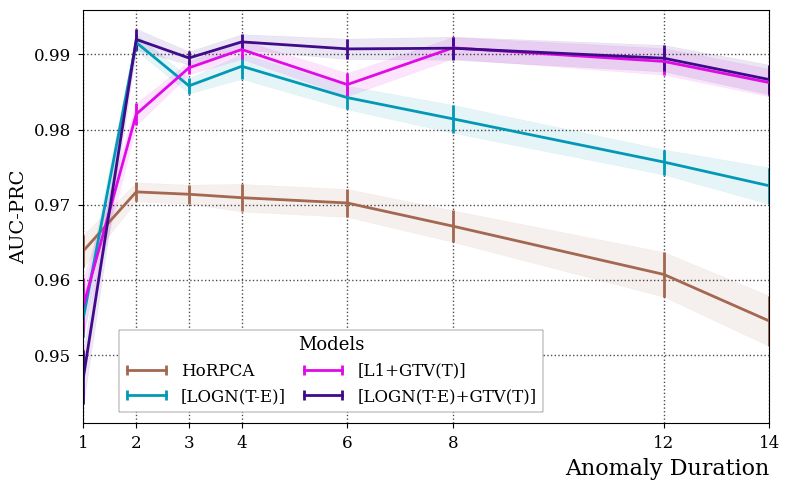

In [12]:
group_name = "duration_exp"
EXP_DIR = SCRIPT_DIR / group_name
EXP_CFG_DIR = EXP_DIR / 'configs'
RES_DIR = EXP_DIR / 'results'
CFG_DIR = SCRIPT_DIR / 'configs'
def load_exp_config(group_name, config_name):
    """
    Load experiment configuration from a YAML file.
    """
    with open(EXP_CFG_DIR / f'{config_name}.yaml') as f:
        exp_config = yaml.safe_load(f)
    return exp_config


config_name = 'temporally_grouped_SL_rel_err_tpe'
# Load the experiment configuration
exp_config = load_exp_config(group_name, config_name)
overwrite = True

independent_var = exp_config['independent_var']
model_configs = exp_config['models']
model_keys = list(model_configs.keys())
model_names = [model_configs[key]['name'] for key in model_keys]

aggregate_path = RES_DIR / f"{config_name}_aggregate_results.csv"
aggregate_df = pd.read_csv(aggregate_path, index_col=['model_name', independent_var['keys'][-1]])
with open(CFG_DIR / 'model_plot_styles.yaml') as f:
    model_styles = yaml.safe_load(f)
model_name_to_key_map = {v['label']: k for k, v in model_styles.items()}


metrics = ['AUC-PRC']#,'F1'] #'S_rel_err', 'L_rel_err']
# metrics = ['AUC-PRC','F1'] #'S_rel_err', 'L_rel_err']
# metrics = ['AUC-PRC','F1', 'Recall'] #'S_rel_err', 'L_rel_err']

# Plotting
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
# fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 8))
# fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 13))
# axes = axes.flatten()
axes = [axes]  # Ensure axes is a list for consistent indexing

# Create bar plots for each metric
for i, metric in enumerate(metrics):
    # if i==0:
    #     axes[i].set_title(f'{metric} Score vs Varying {independent_var["keys"][-1].capitalize()} of Anomalies', fontsize=16)
    for model_name in model_names:
        model_aggregate = aggregate_df.loc[model_name]
        plot_style = model_styles[model_name_to_key_map[model_name]]
        plot_style['label'] = model_name.replace('-f', '').replace('[SNN]-', '')
        plot_style['linestyle'] = '-'
        plot_style['linewidth']=2.0
        axes[i].errorbar(model_aggregate.index,
                    model_aggregate[metric],
                    yerr=model_aggregate[f'std_{metric}'],
                    **plot_style
                    )
        axes[i].fill_between(model_aggregate.index,
                             model_aggregate[metric] -model_aggregate[f'std_{metric}'],
                             model_aggregate[metric] +model_aggregate[f'std_{metric}'],
                             color=plot_style['color'],
                             alpha=0.10)
    axes[i].grid(True, linestyle='--', alpha=0.7, color='k')
    axes[i].set_ylabel(metric, fontsize=14, loc='center')
    # axes[i].tick_params(axis='x', labelsize=12)
    # axes[i].legend(title='Models', fontsize=12, edgecolor='k')
    
    axes[i].set_xlim(aggregate_df.index.get_level_values(independent_var['keys'][-1]).min(),
                    aggregate_df.index.get_level_values(independent_var['keys'][-1]).max())
    axes[i].set_xticks(aggregate_df.index.get_level_values(independent_var['keys'][-1]).unique())
    axes[i].tick_params(axis='both', which='major', labelsize=12, labelrotation=0,
                        grid_linewidth=1, grid_linestyle=':')
    
axes[-1].set_xlabel('Anomaly ' + independent_var['keys'][-1].capitalize(), fontsize=16, loc='right')
handles, labels = axes[-1].get_legend_handles_labels()
handler_map = { h: HandlerErrorbar(numpoints=2, marker_pad=0.1, yerr_size=0.3) for h in handles}

legend_cfg = { 'loc': 'lower center',
               'ncol':2,
               'framealpha':1.0,
            #    'scatterpoints':2,
               'title':'Models',
               'title_fontsize':13,
               'alignment': 'center',
               'fontsize':12,
               'edgecolor':'black',
               'facecolor':'white',
               'numpoints':2,
               'handlelength':2.5,
               'handler_map':handler_map,
               'bbox_transform':fig.transFigure,#axes[-1].transAxes,
            #    'bbox_to_anchor': (0.38, -0.065, 0.0, 0.0),
                'bbox_to_anchor': (0.42, 0.15, 0.0, 0.0),
            #    'bbox_to_anchor': (0.38, -0.02, 0.0, 0.0),
                # 'bbox_to_anchor': (0.38, 0.008, 0.0, 0.0),
               'columnspacing':1.0,
               'fancybox':False,
               'frameon':True,
}
axes[-1].legend(handles, labels, **legend_cfg)
plt.tight_layout()
plt.show()

# Experiment 3: Varying Radius of Anomalies
## Part A: Coherent Spatial Diffusion Type Anomalies

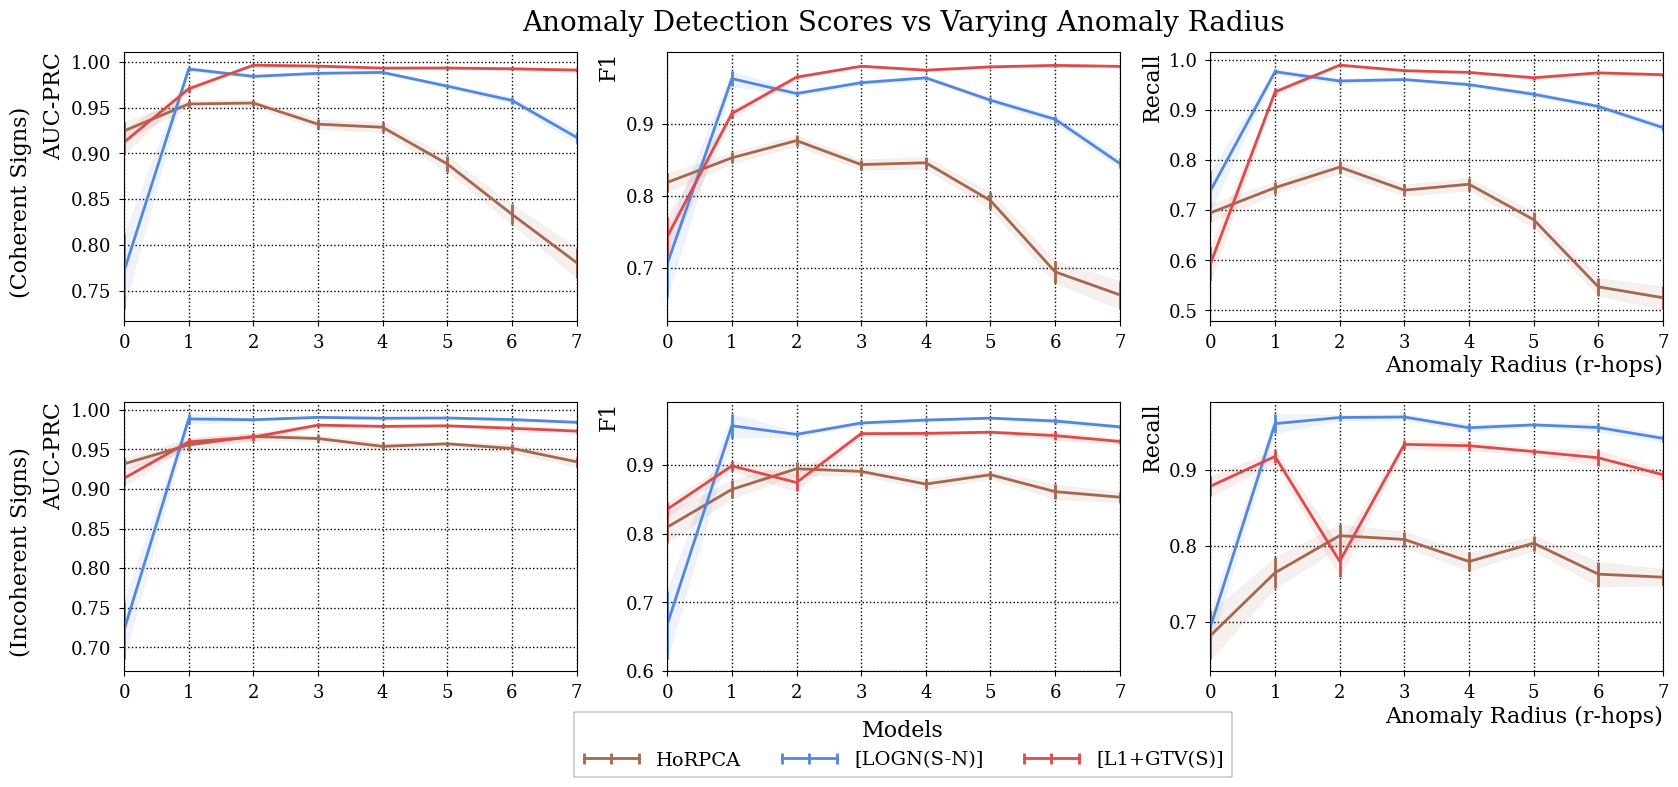

In [262]:
group_name = "radius_exp"
EXP_DIR = SCRIPT_DIR / group_name
EXP_CFG_DIR = EXP_DIR / 'configs'
RES_DIR = EXP_DIR / 'results'
CFG_DIR = SCRIPT_DIR / 'configs'
def load_exp_config(group_name, config_name):
    """
    Load experiment configuration from a YAML file.
    """
    with open(EXP_CFG_DIR / f'{config_name}.yaml') as f:
        exp_config = yaml.safe_load(f)
    return exp_config


config_3a = 'constant_diffusion_SL_rel_err_tpe'
config_3b = 'incoherent_diffusion_SL_rel_err_tpe'

# Load the experiment configuration
exp3a_config = load_exp_config(group_name, config_3a)
exp3b_config = load_exp_config(group_name, config_3b)

independent_var = exp3a_config['independent_var']
model_configs = exp3a_config['models']
model_keys = list(model_configs.keys())
model_names = [model_configs[key]['name'] for key in model_keys]


exp3a_aggregate_path = RES_DIR / f"{config_3a}_aggregate_results.csv"
exp3b_aggregate_path = RES_DIR / f"{config_3b}_aggregate_results.csv"
exp3a_aggregate_df = pd.read_csv(exp3a_aggregate_path, index_col=['model_name', independent_var['keys'][-1]])
exp3b_aggregate_df = pd.read_csv(exp3b_aggregate_path, index_col=['model_name', independent_var['keys'][-1]])
with open(CFG_DIR / 'model_plot_styles.yaml') as f:
    model_styles = yaml.safe_load(f)
model_name_to_key_map = {v['label']: k for k, v in model_styles.items()}

metrics = ['AUC-PRC', 'F1', 'Recall']
dfs = [exp3a_aggregate_df, exp3b_aggregate_df]

fig = plt.figure( figsize=(19, 7))
# fig = plt.figure( figsize=(19, 5))
fig.suptitle('Anomaly Detection Scores vs Varying Anomaly Radius', fontsize=20, y=1)

# Create subfigures for each row
subfigs = fig.subfigures(nrows=2, ncols=1)
# subfigs = fig.subfigures(nrows=1, ncols=1)
subfigs = [subfigs] if not isinstance(subfigs, np.ndarray) else subfigs
rowtitles = ['(Coherent Signs)',
            '(Incoherent Signs)']

for row, subfig in enumerate(subfigs):
    # subfig.suptitle(rowtitles[row], fontsize=16)  # Set the row title
    axes = subfig.subplots(nrows=1, ncols=3) 
    for i, metric in enumerate(metrics):
        for model_name in model_names:
            model_aggregate = dfs[row].loc[model_name]
            plot_style = model_styles[model_name_to_key_map[model_name]]
            plot_style['linewidth']=2.0
            plot_style['label'] = model_name.replace('-f', '').replace('[SNN]-', '')
            plot_style['linestyle'] = '-'
            
            axes[i].errorbar(model_aggregate.index,
                        model_aggregate[metric],
                        yerr=model_aggregate[f'std_{metric}'],
                        **plot_style
                        )
            
            axes[i].fill_between(model_aggregate.index,
                                model_aggregate[metric] -model_aggregate[f'std_{metric}'],
                                model_aggregate[metric] +model_aggregate[f'std_{metric}'],
                                color=plot_style['color'],
                                alpha=0.10)
            
            
        # axes[i].grid(True, linestyle='--', alpha=0.7, color='k')
        axes[i].grid(True, linestyle=':', alpha=1.0, color='k')
        axes[i].set_ylabel(metric, fontsize=16, loc='top')
        # axes[i].legend(title='Models', fontsize=12, edgecolor='k')
        axes[i].set_xlabel(None)
        # axes[i].set_xlabel(independent_var['keys'][-1].capitalize(), fontsize=14, loc='right')
        axes[i].set_xlim(dfs[row].index.get_level_values(independent_var['keys'][-1]).min(),
                        dfs[row].index.get_level_values(independent_var['keys'][-1]).max())
        axes[i].set_xticks(dfs[row].index.get_level_values(independent_var['keys'][-1]).unique())
        axes[i].tick_params(axis='both', which='major', labelsize=13, labelrotation=0,
                        grid_linewidth=1, grid_linestyle=':')
    subfig.supxlabel('Anomaly Radius (r-hops)', fontsize=16, x=0.9, y=-0.05, ha='right')
    subfig.supylabel(rowtitles[row], fontsize=16, y=0.45, x=0.03)
    # subfig.supxlabel(independent_var['keys'][-1].capitalize(), fontsize=16, x=0.9, y=-0.02, ha='right')
    subfig.subplots_adjust(left=0.09)

# subfig.supxlabel('Anomaly Radius (r-hops)', fontsize=16, x=0.9, y=-0.05, ha='right')
# axes[-1].set_xlabel(independent_var['keys'][-1].capitalize(), fontsize=16, loc='right')
handles, labels = axes[-1].get_legend_handles_labels()
handler_map = { h: HandlerErrorbar(numpoints=3, marker_pad=0.1, yerr_size=0.3) for h in handles}

legend_cfg = { 'loc': 'lower center',
               'ncol':3,
               'framealpha':1.0,
               'title':'Models',
               'title_fontsize':16,
               'alignment': 'center',
               'fontsize':14,
               'edgecolor':'black',
               'facecolor':'white',
               'numpoints':2,
               'handlelength':3,
               'handler_map':handler_map,
               'bbox_transform':fig.transFigure,#axes[-1].transAxes,
            #    'bbox_to_anchor': (0.5, -0.065, 0.0, 0.0),
               'bbox_to_anchor': (0.5, -0.11, 0.0, 0.0),
               'columnspacing':2.0,
               'fancybox':False,
               'frameon':True,
}
axes[-1].legend(handles, labels, **legend_cfg)


# fig.tight_layout()
# fig.subplots_adjust(hspace=0)
plt.show()

## Part B: Incoherent Spatial Diffusion Type Anomalies

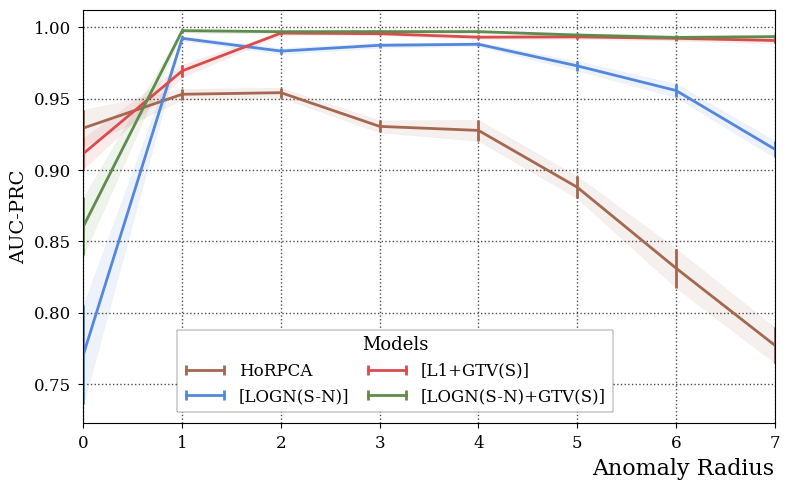

: 

In [ ]:
group_name = "radius_exp"
EXP_DIR = SCRIPT_DIR / group_name
EXP_CFG_DIR = EXP_DIR / 'configs'
RES_DIR = EXP_DIR / 'results'
CFG_DIR = SCRIPT_DIR / 'configs'
def load_exp_config(group_name, config_name):
    """
    Load experiment configuration from a YAML file.
    """
    with open(EXP_CFG_DIR / f'{config_name}.yaml') as f:
        exp_config = yaml.safe_load(f)
    return exp_config


config_3a = 'constant_diffusion_SL_rel_err_tpe'
config_3b = 'incoherent_diffusion_SL_rel_err_tpe'

# Load the experiment configuration
exp3a_config = load_exp_config(group_name, config_3a)
exp3b_config = load_exp_config(group_name, config_3b)

independent_var = exp3a_config['independent_var']
model_configs = exp3a_config['models']
model_keys = list(model_configs.keys())
model_names = [model_configs[key]['name'] for key in model_keys]


exp3a_aggregate_path = RES_DIR / f"{config_3a}_aggregate_results.csv"
exp3b_aggregate_path = RES_DIR / f"{config_3b}_aggregate_results.csv"
exp3a_aggregate_df = pd.read_csv(exp3a_aggregate_path, index_col=['model_name', independent_var['keys'][-1]])
exp3b_aggregate_df = pd.read_csv(exp3b_aggregate_path, index_col=['model_name', independent_var['keys'][-1]])
with open(CFG_DIR / 'model_plot_styles.yaml') as f:
    model_styles = yaml.safe_load(f)
model_name_to_key_map = {v['label']: k for k, v in model_styles.items()}

metrics = ['AUC-PRC']#, 'F1', 'Recall']
dfs = [exp3a_aggregate_df, exp3b_aggregate_df]

# fig = plt.figure( figsize=(19, 7))

# fig = plt.figure( figsize=(19, 5))
# fig.suptitle('Anomaly Detection Scores vs Varying Anomaly Radius', fontsize=20, y=1)

# # Create subfigures for each row
# subfigs = fig.subfigures(nrows=2, ncols=1)
# # subfigs = fig.subfigures(nrows=1, ncols=1)
# subfigs = [subfigs] if not isinstance(subfigs, np.ndarray) else subfigs
# rowtitles = ['(Coherent Signs)',
#             '(Incoherent Signs)']


metrics = ['AUC-PRC']#,'F1'] #'S_rel_err', 'L_rel_err']
# metrics = ['AUC-PRC','F1'] #'S_rel_err', 'L_rel_err']
# metrics = ['AUC-PRC','F1', 'Recall'] #'S_rel_err', 'L_rel_err']

# Plotting
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
# fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 8))
# fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 13))
# axes = axes.flatten()
axes = [axes]  # Ensure axes is a list for consistent indexing
aggregate_df = exp3a_aggregate_df
# Create bar plots for each metric
for i, metric in enumerate(metrics):
    # if i==0:
    #     axes[i].set_title(f'{metric} Score vs Varying {independent_var["keys"][-1].capitalize()} of Anomalies', fontsize=16)
    for model_name in model_names:
        model_aggregate = aggregate_df.loc[model_name]
        plot_style = model_styles[model_name_to_key_map[model_name]]
        plot_style['label'] = model_name.replace('-f', '').replace('[SNN]-', '')
        plot_style['linestyle'] = '-'
        plot_style['linewidth']=2.0
        axes[i].errorbar(model_aggregate.index,
                    model_aggregate[metric],
                    yerr=model_aggregate[f'std_{metric}'],
                    **plot_style
                    )
        axes[i].fill_between(model_aggregate.index,
                             model_aggregate[metric] -model_aggregate[f'std_{metric}'],
                             model_aggregate[metric] +model_aggregate[f'std_{metric}'],
                             color=plot_style['color'],
                             alpha=0.10)
    axes[i].grid(True, linestyle='--', alpha=0.7, color='k')
    axes[i].set_ylabel(metric, fontsize=14, loc='center')
    # axes[i].tick_params(axis='x', labelsize=12)
    # axes[i].legend(title='Models', fontsize=12, edgecolor='k')
    
    axes[i].set_xlim(aggregate_df.index.get_level_values(independent_var['keys'][-1]).min(),
                    aggregate_df.index.get_level_values(independent_var['keys'][-1]).max())
    axes[i].set_xticks(aggregate_df.index.get_level_values(independent_var['keys'][-1]).unique())
    axes[i].tick_params(axis='both', which='major', labelsize=12, labelrotation=0,
                        grid_linewidth=1, grid_linestyle=':')
    
axes[-1].set_xlabel('Anomaly ' + independent_var['keys'][-1].capitalize(), fontsize=16, loc='right')
handles, labels = axes[-1].get_legend_handles_labels()
handler_map = { h: HandlerErrorbar(numpoints=2, marker_pad=0.1, yerr_size=0.3) for h in handles}

legend_cfg = { 'loc': 'lower center',
               'ncol':2,
               'framealpha':1.0,
            #    'scatterpoints':2,
               'title':'Models',
               'title_fontsize':13,
               'alignment': 'center',
               'fontsize':12,
               'edgecolor':'black',
               'facecolor':'white',
               'numpoints':2,
               'handlelength':2.5,
               'handler_map':handler_map,
               'bbox_transform':fig.transFigure,#axes[-1].transAxes,
            #    'bbox_to_anchor': (0.38, -0.065, 0.0, 0.0),
                'bbox_to_anchor': (0.5, 0.15, 0.0, 0.0),
            #    'bbox_to_anchor': (0.38, -0.02, 0.0, 0.0),
                # 'bbox_to_anchor': (0.38, 0.008, 0.0, 0.0),
               'columnspacing':1.0,
               'fancybox':False,
               'frameon':True,
}
axes[-1].legend(handles, labels, **legend_cfg)
plt.tight_layout()
plt.show()